# Covid-19 Diagnoise based on Chest x-ray 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install tensorflow==2.2.0 keras==2.3.1

     |████████████████████████████████| 516.2MB 32kB/s 
     |████████████████████████████████| 378kB 53.2MB/s 
     |████████████████████████████████| 3.0MB 45.1MB/s 
     |████████████████████████████████| 460kB 50.2MB/s 
     |████████████████████████████████| 51kB 8.9MB/s 
  Found existing installation: tensorboard 2.4.1
    Uninstalling tensorboard-2.4.1:
      Successfully uninstalled tensorboard-2.4.1
  Found existing installation: tensorflow-estimator 2.4.0
    Uninstalling tensorflow-estimator-2.4.0:
      Successfully uninstalled tensorflow-estimator-2.4.0
  Found existing installation: tensorflow 2.4.1
    Uninstalling tensorflow-2.4.1:
      Successfully uninstalled tensorflow-2.4.1
  Found existing installation: Keras 2.4.3
    Uninstalling Keras-2.4.3:
      Successfully uninstalled Keras-2.4.3


In [ ]:
import tensorflow
tensorflow.__version__

'2.2.0'

In [4]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

Using TensorFlow backend.


In [5]:
#SEARCHING FOR P100
import os
import time
x=!nvidia-smi
count=0
for i in x:
    if "============" in i:
        count+=1
        break
    count+=1
if 'p100' in x[count].lower():
    print("found")
else:
    print(x[count])
    time.sleep(1)
    #os._exit(00)

|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |


In [6]:
import tensorflow
from tensorflow.python.client import device_lib 
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 10922675055152444973
, name: "/device:XLA_CPU:0"
device_type: "XLA_CPU"
memory_limit: 17179869184
locality {
}
incarnation: 11337584239017290695
physical_device_desc: "device: XLA_CPU device"
, name: "/device:XLA_GPU:0"
device_type: "XLA_GPU"
memory_limit: 17179869184
locality {
}
incarnation: 6925366966622362804
physical_device_desc: "device: XLA_GPU device"
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14792560512
locality {
  bus_id: 1
  links {
  }
}
incarnation: 4733548554046732537
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
]


In [7]:
# Resizinig all the images to (224,224)
IMAGE_SIZE = [224,224]

train_path = '/content/drive/MyDrive/skin2/train'
test_path = '/content/drive/MyDrive/skin2/test'

In [8]:
# Scaling all the images between 0 to 1

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=False)

# Performing only scaling on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(224,224),
                                              batch_size=32,
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(224,224),
                                            batch_size=32,
                                            class_mode='categorical')

Found 187 images belonging to 10 classes.
Found 187 images belonging to 10 classes.


# **ResNet**

In [10]:
resnet = ResNet50(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

94773248/94765736 [==============================] - 2s 0us/step


In [11]:
for layer in resnet.layers:
  layer.trainable = False

In [12]:
folder = glob('/content/drive/MyDrive/skin2/*')
folder

['/content/drive/MyDrive/skin2/Notebook.ipynb',
 '/content/drive/MyDrive/skin2/test.py',
 '/content/drive/MyDrive/skin2/test',
 '/content/drive/MyDrive/skin2/train']

In [13]:
x = Flatten()(resnet.output)

In [14]:
prediction = Dense(10, activation='softmax')(x)

In [15]:
model = Model(inputs = resnet.inputs, outputs = prediction)
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1_conv[0][0]                 
______________________________________________________________________________________________

In [16]:
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
hist = model.fit_generator(train_set, validation_data=test_set, epochs=200, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[callback])

Instructions for updating:
Please use Model.fit, which supports generators.
Epoch 1/20
6/6 [==============================] - 105s 18s/step - loss: 9.9050 - accuracy: 0.0856 - val_loss: 12.1084 - val_accuracy: 0.1016
Epoch 2/20
6/6 [==============================] - 4s 670ms/step - loss: 14.7446 - accuracy: 0.1283 - val_loss: 10.6277 - val_accuracy: 0.0963
Epoch 3/20
6/6 [==============================] - 4s 681ms/step - loss: 7.4951 - accuracy: 0.0749 - val_loss: 7.6683 - val_accuracy: 0.1016
Epoch 4/20
6/6 [==============================] - 4s 689ms/step - loss: 7.2916 - accuracy: 0.1176 - val_loss: 5.4371 - val_accuracy: 0.1444
Epoch 5/20
6/6 [==============================] - 4s 676ms/step - loss: 4.7314 - accuracy: 0.1497 - val_loss: 2.6408 - val_accuracy: 0.1658
Epoch 6/20
6/6 [==============================] - 4s 673ms/step - loss: 3.7377 - accuracy: 0.1390 - val_loss: 3.3586 - val_accuracy: 0.1925
Epoch 7/20
6/6 [==============================] - 4s 675ms/step - loss: 3.3855 - 

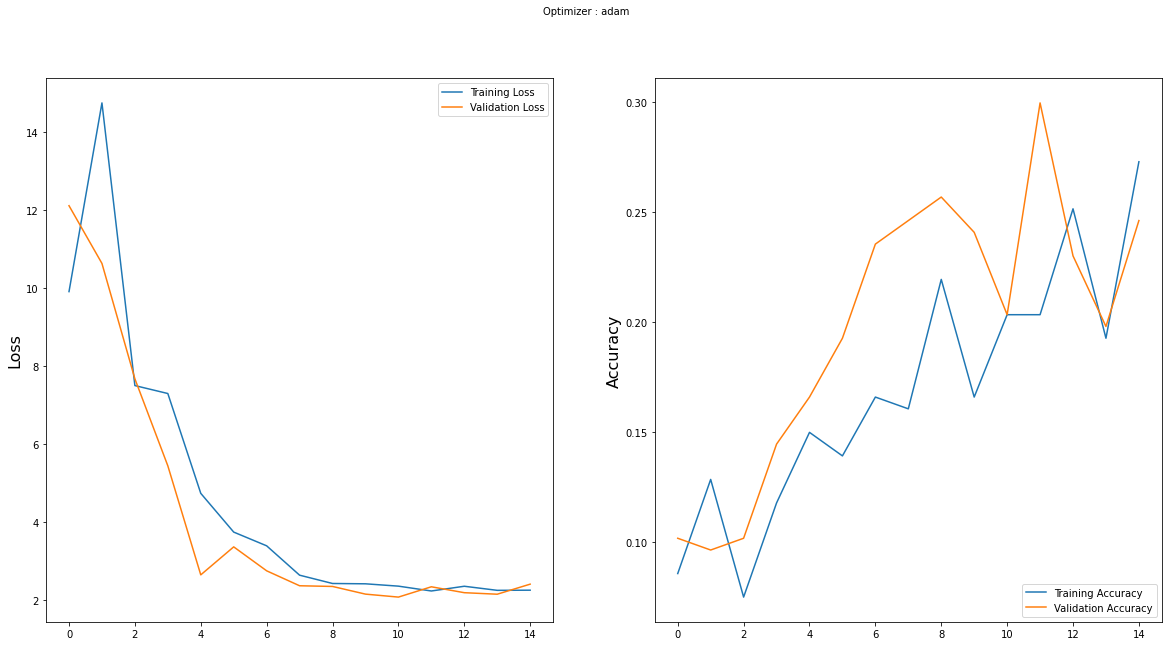

In [18]:
import matplotlib.pyplot as plt

x=hist
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
y_p=model.predict(test_set,verbose=1,steps=len(test_set))
y_pr=np.argmax(y_p,axis=1)
cm1=confusion_matrix(test_set.classes,y_pr)
total1=sum(sum(cm1))
#from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)
print(classification_report(test_set.classes, y_pr))

2/2 [==============================] - 0s 207ms/step
Accuracy :  0.3829787234042553
Sensitivity :  0.09523809523809523
Specificity :  0.7619047619047619
              precision    recall  f1-score   support

           0       0.25      0.10      0.14        21
           1       0.41      0.76      0.53        21
           2       0.00      0.00      0.00         5

    accuracy                           0.38        47
   macro avg       0.22      0.29      0.22        47
weighted avg       0.30      0.38      0.30        47



/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# **For InceptionV3 with optimiser adam**

In [19]:
# create the base pre-trained model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x2 = base_model.output
x2 = GlobalAveragePooling2D()(x2)

87916544/87910968 [==============================] - 1s 0us/step


In [20]:
predictions = Dense(10, activation='softmax')(x2)

# this is the model we will train
models = Model(inputs=base_model.input, outputs=predictions)
models.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, None, None, 3 864         input_2[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, None, None, 3 96          conv2d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, None, None, 3 0           batch_normalization[0][0]        
____________________________________________________________________________________________

In [21]:
for layer in base_model.layers:
    layer.trainable = False


In [22]:
models.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
hist = models.fit_generator(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[callback])

Epoch 1/20
6/6 [==============================] - 6s 940ms/step - loss: 2.5056 - accuracy: 0.1123 - val_loss: 2.0113 - val_accuracy: 0.2995
Epoch 2/20
6/6 [==============================] - 4s 681ms/step - loss: 1.9647 - accuracy: 0.3048 - val_loss: 1.6188 - val_accuracy: 0.5294
Epoch 3/20
6/6 [==============================] - 4s 658ms/step - loss: 1.6238 - accuracy: 0.4759 - val_loss: 1.3619 - val_accuracy: 0.6043
Epoch 4/20
6/6 [==============================] - 4s 659ms/step - loss: 1.3616 - accuracy: 0.6096 - val_loss: 1.1497 - val_accuracy: 0.6898
Epoch 5/20
6/6 [==============================] - 4s 658ms/step - loss: 1.1696 - accuracy: 0.6524 - val_loss: 1.0081 - val_accuracy: 0.6952
Epoch 6/20
6/6 [==============================] - 4s 671ms/step - loss: 0.9890 - accuracy: 0.7219 - val_loss: 0.8779 - val_accuracy: 0.7861
Epoch 7/20
6/6 [==============================] - 4s 669ms/step - loss: 0.8804 - accuracy: 0.7807 - val_loss: 0.7801 - val_accuracy: 0.8075
Epoch 8/20
6/6 [====

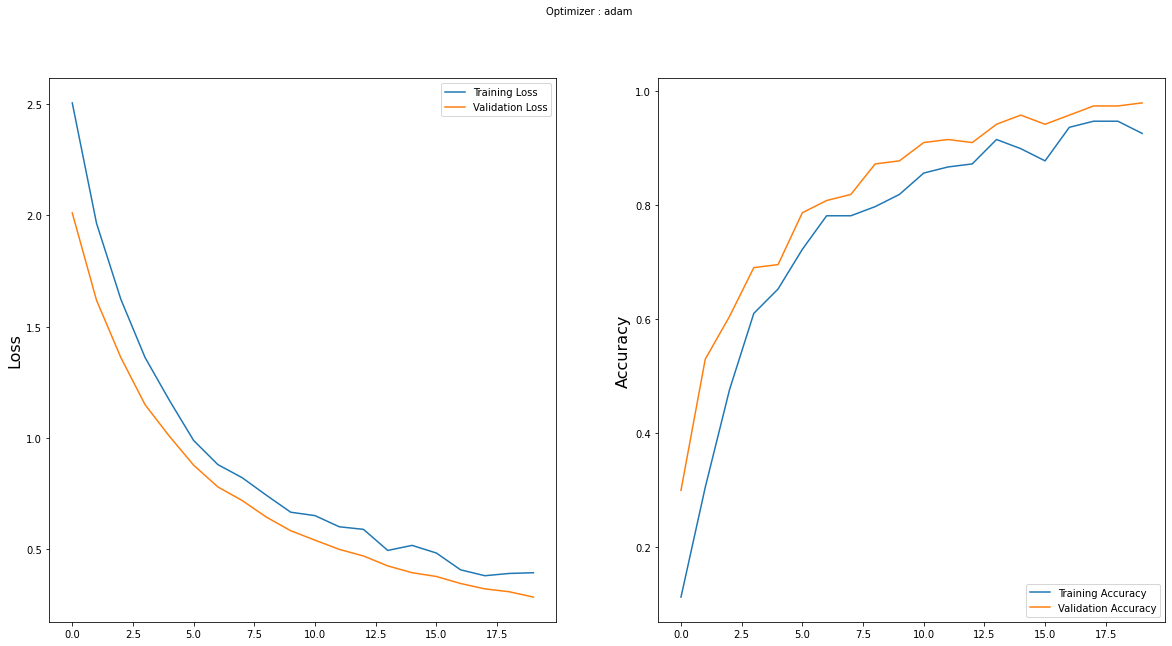

In [23]:
import matplotlib.pyplot as plt

x=hist
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# **FOR VGG16**

In [25]:
vgg16=VGG16(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

58892288/58889256 [==============================] - 0s 0us/step


In [26]:
x1= Flatten()(vgg16.output)
prediction1 = Dense(10, activation='softmax')(x1)
model1 = Model(inputs = vgg16.inputs, outputs = prediction1)
model1.summary()
model1.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0   

In [27]:
r1 = model1.fit_generator(train_set, validation_data=test_set, epochs=200, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/20
6/6 [==============================] - 11s 2s/step - loss: 8.1095 - accuracy: 0.0909 - val_loss: 2.3169 - val_accuracy: 0.1176
Epoch 2/20
6/6 [==============================] - 5s 803ms/step - loss: 2.3596 - accuracy: 0.0856 - val_loss: 2.3037 - val_accuracy: 0.1016
Epoch 3/20
6/6 [==============================] - 5s 776ms/step - loss: 2.3551 - accuracy: 0.0856 - val_loss: 2.3092 - val_accuracy: 0.0963
Epoch 4/20
6/6 [==============================] - 5s 777ms/step - loss: 2.3181 - accuracy: 0.1230 - val_loss: 2.3042 - val_accuracy: 0.1016
Epoch 5/20
6/6 [==============================] - 5s 793ms/step - loss: 2.3010 - accuracy: 0.0963 - val_loss: 2.3052 - val_accuracy: 0.0856
Epoch 6/20
6/6 [==============================] - 5s 774ms/step - loss: 2.3035 - accuracy: 0.1070 - val_loss: 2.3022 - val_accuracy: 0.1070
Epoch 7/20
6/6 [==============================] - 5s 779ms/step - loss: 2.3044 - accuracy: 0.1070 - val_loss: 2.3021 - val_accuracy: 0.1070
Epoch 8/20
6/6 [======

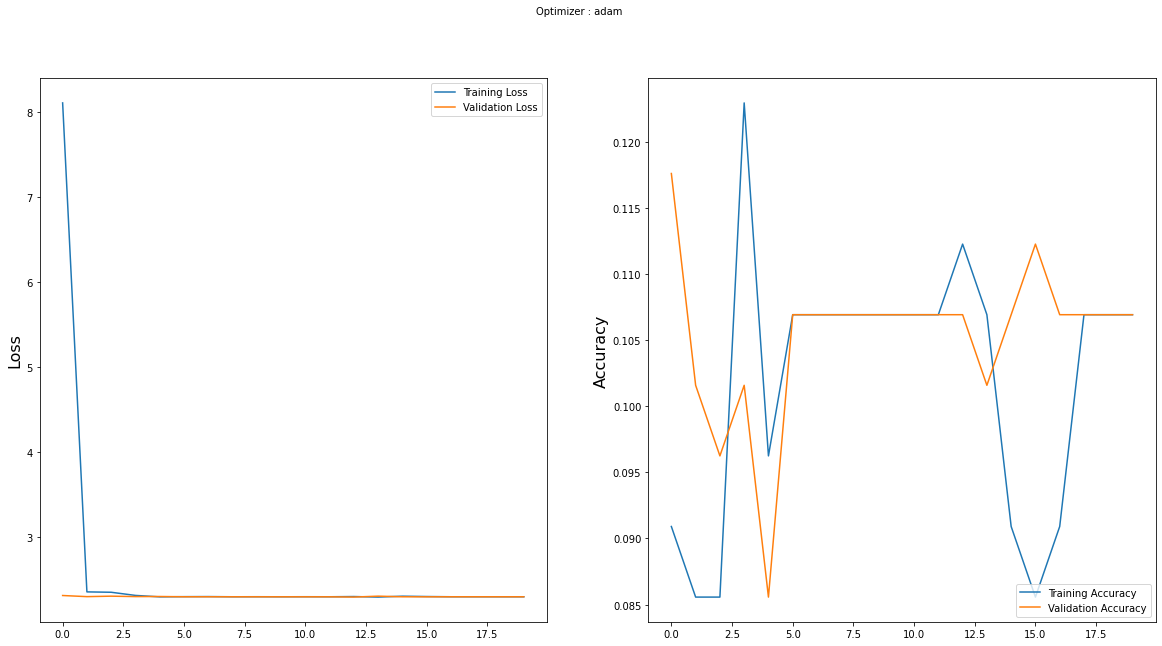

In [28]:
import matplotlib.pyplot as plt

x=r1
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# **VGG19**

In [29]:
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.models import Model
vgg19=VGG19(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

80142336/80134624 [==============================] - 0s 0us/step


In [30]:
x11= Flatten()(vgg19.output)
prediction11 = Dense(10, activation='softmax')(x11)
model11 = Model(inputs = vgg19.inputs, outputs = prediction11)
model11.summary()
model11.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0   

In [31]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
hist = model11.fit_generator(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[callback])

Epoch 1/20
6/6 [==============================] - 5s 833ms/step - loss: 9.0159 - accuracy: 0.1016 - val_loss: 2.3054 - val_accuracy: 0.1070
Epoch 2/20
6/6 [==============================] - 5s 817ms/step - loss: 2.3884 - accuracy: 0.0909 - val_loss: 2.3127 - val_accuracy: 0.1070
Epoch 3/20
6/6 [==============================] - 5s 811ms/step - loss: 2.5072 - accuracy: 0.1070 - val_loss: 2.3025 - val_accuracy: 0.1070
Epoch 4/20
6/6 [==============================] - 5s 815ms/step - loss: 2.3083 - accuracy: 0.0909 - val_loss: 2.3002 - val_accuracy: 0.1123
Epoch 5/20
6/6 [==============================] - 5s 839ms/step - loss: 2.3657 - accuracy: 0.1016 - val_loss: 2.3014 - val_accuracy: 0.1070
Epoch 6/20
6/6 [==============================] - 5s 818ms/step - loss: 2.3104 - accuracy: 0.1123 - val_loss: 2.3030 - val_accuracy: 0.1016
Epoch 7/20
6/6 [==============================] - 5s 808ms/step - loss: 2.3112 - accuracy: 0.0802 - val_loss: 2.3020 - val_accuracy: 0.1070


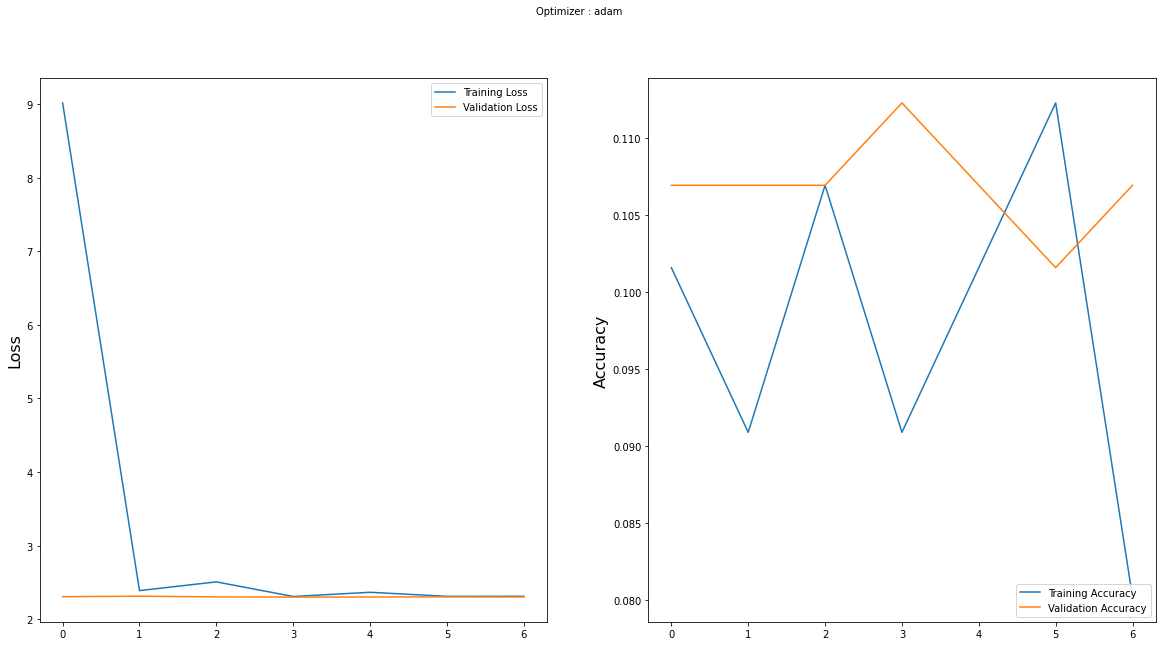

In [32]:
import matplotlib.pyplot as plt

x=hist
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()


# **INCEPTION RESNET V2**

In [35]:
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.models import Model
inc=InceptionResNetV2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [36]:
x3 = Flatten()(inc.output)
predictionss = Dense(10, activation='softmax')(x3)

In [37]:
modelss = Model(inputs = inc.inputs, outputs = predictionss)
modelss.summary()

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv2d_94 (Conv2D)              (None, 111, 111, 32) 864         input_6[0][0]                    
__________________________________________________________________________________________________
batch_normalization_94 (BatchNo (None, 111, 111, 32) 96          conv2d_94[0][0]                  
__________________________________________________________________________________________________
activation_94 (Activation)      (None, 111, 111, 32) 0           batch_normalization_94[0][0]     
____________________________________________________________________________________________

In [38]:
modelss.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
r2 = modelss.fit_generator(train_set, validation_data=test_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(test_set))
x=r2

Epoch 1/20
6/6 [==============================] - 10s 2s/step - loss: 4.5060 - accuracy: 0.1765 - val_loss: 5.0898 - val_accuracy: 0.1872
Epoch 2/20
6/6 [==============================] - 5s 848ms/step - loss: 2.5202 - accuracy: 0.4439 - val_loss: 5.3940 - val_accuracy: 0.2460
Epoch 3/20
6/6 [==============================] - 5s 850ms/step - loss: 1.7679 - accuracy: 0.6578 - val_loss: 29.6838 - val_accuracy: 0.1497
Epoch 4/20
6/6 [==============================] - 5s 878ms/step - loss: 0.8406 - accuracy: 0.7968 - val_loss: 130.1932 - val_accuracy: 0.1230
Epoch 5/20
6/6 [==============================] - 5s 846ms/step - loss: 1.0183 - accuracy: 0.9144 - val_loss: 727.3412 - val_accuracy: 0.1230
Epoch 6/20
6/6 [==============================] - 5s 843ms/step - loss: 1.5399 - accuracy: 0.9358 - val_loss: 73.6465 - val_accuracy: 0.1176
Epoch 7/20
6/6 [==============================] - 5s 836ms/step - loss: 1.0258 - accuracy: 0.9251 - val_loss: 119.5489 - val_accuracy: 0.1497
Epoch 8/20
6/6

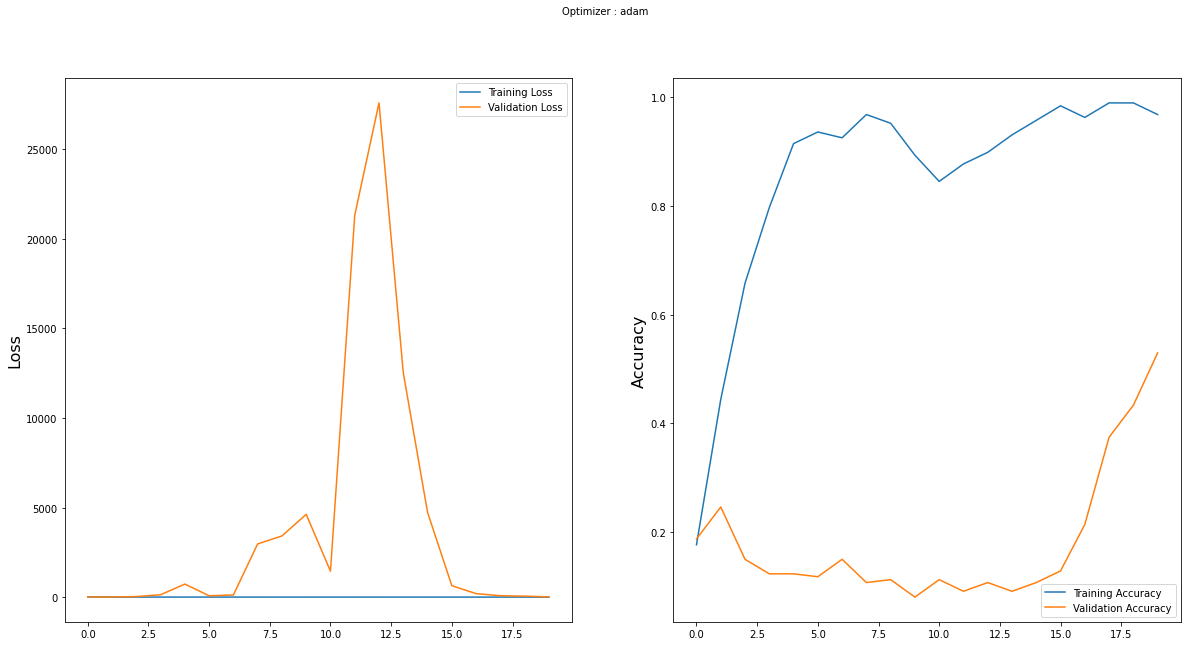

In [39]:
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [40]:
from tensorflow.keras.models import load_model

models.save('/content/drive/MyDrive/skin2/model.h5')